# Chercher par le sens : les *embeddings*

Un modèle d'*embeddings* transforme un texte en un vecteur de quelques centaines de nombres, de sorte que deux textes de sens proche aient des vecteurs proches, même sans mot en commun. C'est le moteur de recherche d'un RAG.

Le modèle : [multilingual-e5-base](https://huggingface.co/intfloat/multilingual-e5-base), multilingue. Il attend un préfixe devant chaque texte : `query: ` pour une question, `passage: ` pour un texte où chercher. Pas besoin de GPU.

In [1]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE

embedder = SentenceTransformer("intfloat/multilingual-e5-base")


def embed(texts, prefix: str = "query: ") -> np.ndarray:
    if isinstance(texts, str):
        return embedder.encode(prefix + texts, normalize_embeddings=True)
    return embedder.encode([prefix + t for t in texts], normalize_embeddings=True)

## Un texte, un vecteur

In [2]:
vector = embed("Mon VPN ne fonctionne plus")
print(vector.shape)
vector[:8]

(768,)


array([ 0.02934561,  0.04345581, -0.00930471, -0.00164101,  0.01848622,
       -0.05887549, -0.02787426, -0.00779176], dtype=float32)

Ces nombres n'ont pas de sens un par un : seule la **position** du vecteur compte, par rapport à celle des autres.

## Comparer deux phrases

La similarité cosinus mesure si deux vecteurs pointent dans la même direction : 1 pour des vecteurs identiques. Avec ce modèle, même deux phrases sans rapport dépassent 0,8 : seule la **comparaison** des scores a un sens.

In [3]:
def similarity(a: str, b: str) -> float:
    va, vb = embed([a, b])
    return float(va @ vb)


PAIRS = [
    ("Mon VPN ne fonctionne plus", "Impossible de me connecter au réseau de l'entreprise depuis chez moi"),
    ("Mon VPN ne fonctionne plus", "La cantine ferme à 14 h"),
    ("J'ai reçu un e-mail suspect", "Un message frauduleux est arrivé dans ma boîte"),
    ("Mon mot de passe a expiré", "My password has expired"),
    ("Le VPN fonctionne", "Le VPN ne fonctionne pas"),
]
pd.DataFrame([(a, b, round(similarity(a, b), 2)) for a, b in PAIRS], columns=["phrase 1", "phrase 2", "similarité"])

,phrase 1,phrase 2,similarité
0,Mon VPN ne fonctionne plus,Impossible de me connecter au réseau de l'entr...,0.89
1,Mon VPN ne fonctionne plus,La cantine ferme à 14 h,0.86
2,J'ai reçu un e-mail suspect,Un message frauduleux est arrivé dans ma boîte,0.94
3,Mon mot de passe a expiré,My password has expired,0.92
4,Le VPN fonctionne,Le VPN ne fonctionne pas,0.96


- La première paire n'a aucun mot en commun, mais un sens proche : score plus élevé que la deuxième
- Le modèle est multilingue : une phrase et sa traduction sont presque confondues
- Attention à la dernière paire : une négation inverse le sens, mais le score est le plus élevé du tableau. Les *embeddings* captent le **sujet** bien mieux que les détails

## Une carte du sens

Projetons en deux dimensions (avec l'algorithme t-SNE, qui préserve les voisinages) les vecteurs de phrases sur quatre sujets. Les phrases se regroupent par sujet, sans qu'on ait jamais indiqué ces sujets au modèle.

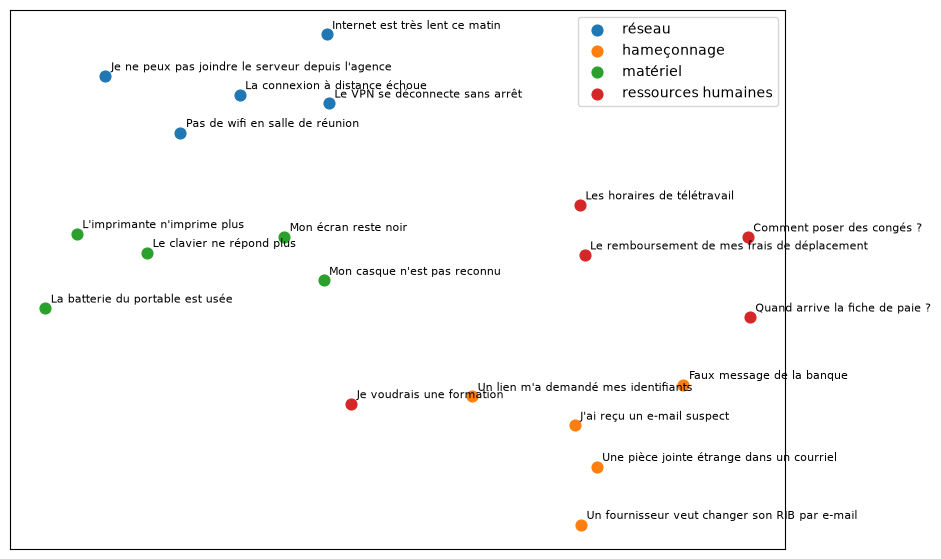

In [4]:
SENTENCES = {
    "réseau": ["Le VPN se déconnecte sans arrêt", "Pas de wifi en salle de réunion",
               "Internet est très lent ce matin", "Je ne peux pas joindre le serveur depuis l'agence",
               "La connexion à distance échoue"],
    "hameçonnage": ["J'ai reçu un e-mail suspect", "Un lien m'a demandé mes identifiants",
                    "Faux message de la banque", "Un fournisseur veut changer son RIB par e-mail",
                    "Une pièce jointe étrange dans un courriel"],
    "matériel": ["L'imprimante n'imprime plus", "Mon écran reste noir",
                 "Le clavier ne répond plus", "La batterie du portable est usée",
                 "Mon casque n'est pas reconnu"],
    "ressources humaines": ["Comment poser des congés ?", "Quand arrive la fiche de paie ?",
                            "Je voudrais une formation", "Le remboursement de mes frais de déplacement",
                            "Les horaires de télétravail"],
}
texts = [s for group in SENTENCES.values() for s in group]
topics = [topic for topic, group in SENTENCES.items() for _ in group]
vectors = embed(texts)
points = TSNE(n_components=2, perplexity=5, init="pca", random_state=0).fit_transform(vectors)

fig, ax = plt.subplots(figsize=(10, 7))
for topic in SENTENCES:
    mask = np.array(topics) == topic
    ax.scatter(points[mask, 0], points[mask, 1], label=topic, s=60)
for (x, y), text in zip(points, texts):
    ax.annotate(text, (x, y), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.legend()
ax.set_xticks([])
ax.set_yticks([])
plt.show()

## Chercher par mots-clés ou par le sens

Une petite FAQ du support informatique, et deux façons de la fouiller : compter les mots en commun avec la question, ou comparer les vecteurs.

In [5]:
FAQ = [
    "VPN : pour travailler à distance, installer le client VPN et s'identifier avec son compte Windows.",
    "Code d'erreur VPN -7200 : le certificat du serveur a changé, mettre à jour le client.",
    "Code d'erreur VPN -7250 : le compte est verrouillé, attendre 30 minutes.",
    "Mot de passe oublié : le réinitialiser sur le portail en libre-service.",
    "Double authentification : en cas de changement de téléphone, contacter le support.",
    "E-mail suspect : ne pas cliquer, le signaler avec le bouton « Signaler » d'Outlook.",
    "Perte ou vol d'un ordinateur : prévenir immédiatement le support et la sécurité.",
    "Imprimantes : la liste des imprimantes par étage est sur l'intranet.",
    "Logiciels : les demandes d'installation passent par le catalogue de logiciels.",
    "Boîte mail pleine : archiver les anciens messages ou demander plus d'espace.",
    "Wifi invités : le code change chaque lundi, il est affiché à l'accueil.",
    "Télétravail : le matériel prêté (écran, clavier) se demande à son responsable.",
    "Fichiers partagés : les droits d'accès sont accordés par le responsable du dossier.",
]
faq_vectors = embed(FAQ, prefix="passage: ")
STOPWORDS = {"je", "j", "de", "la", "le", "les", "un", "une", "des", "du", "à", "a", "et", "ne", "pas", "plus",
             "me", "mon", "ma", "mes", "sur", "en", "pour", "par", "avec", "est", "l", "d", "il", "on", "ai"}


def words(text: str) -> set[str]:
    return set(re.findall(r"[\w-]+", text.lower())) - STOPWORDS


def keyword_search(question: str, k: int = 3) -> list[tuple[int, str]]:
    scores = [len(words(question) & words(entry)) for entry in FAQ]
    return [(scores[i], FAQ[i]) for i in np.argsort(scores)[::-1][:k]]


def semantic_search(question: str, k: int = 3) -> list[tuple[float, str]]:
    scores = faq_vectors @ embed(question)
    return [(round(float(scores[i]), 2), FAQ[i]) for i in np.argsort(scores)[::-1][:k]]


def compare(question: str) -> None:
    print("Question :", question)
    print("\nPar mots-clés (mots en commun) :")
    for score, entry in keyword_search(question):
        print(f"  {score}  {entry}")
    print("\nPar le sens (similarité) :")
    for score, entry in semantic_search(question):
        print(f"  {score}  {entry}")


compare("Je n'arrive plus à me connecter au travail depuis chez moi")

Question : Je n'arrive plus à me connecter au travail depuis chez moi

Par mots-clés (mots en commun) :
  0  Fichiers partagés : les droits d'accès sont accordés par le responsable du dossier.
  0  Télétravail : le matériel prêté (écran, clavier) se demande à son responsable.
  0  Wifi invités : le code change chaque lundi, il est affiché à l'accueil.

Par le sens (similarité) :
  0.8  VPN : pour travailler à distance, installer le client VPN et s'identifier avec son compte Windows.
  0.79  Mot de passe oublié : le réinitialiser sur le portail en libre-service.
  0.79  Télétravail : le matériel prêté (écran, clavier) se demande à son responsable.


Aucun mot de la question ne figure dans la bonne réponse : la recherche par mots-clés échoue, la recherche par le sens la trouve. Mais l'inverse existe :

In [6]:
compare("J'ai l'erreur -7200")

Question : J'ai l'erreur -7200

Par mots-clés (mots en commun) :
  2  Code d'erreur VPN -7200 : le certificat du serveur a changé, mettre à jour le client.
  1  Code d'erreur VPN -7250 : le compte est verrouillé, attendre 30 minutes.
  0  Wifi invités : le code change chaque lundi, il est affiché à l'accueil.

Par le sens (similarité) :
  0.84  Code d'erreur VPN -7200 : le certificat du serveur a changé, mettre à jour le client.
  0.83  Code d'erreur VPN -7250 : le compte est verrouillé, attendre 30 minutes.
  0.79  Mot de passe oublié : le réinitialiser sur le portail en libre-service.


La recherche par le sens trouve bien le bon code, mais d'un cheveu devant le code voisin : pour elle, deux codes d'erreur VPN se ressemblent. Un code, une référence produit, un nom propre : les mots-clés les trouvent à coup sûr, le sens pas toujours. Les RAG en production combinent les deux : c'est la **recherche hybride**.

## À vous

Posez votre propre question à la FAQ (dans Colab, le champ de saisie apparaît à droite de la cellule).

In [7]:
QUESTION = "Mon ordinateur a été volé dans le train"  # @param {type: "string"}

compare(QUESTION)

Question : Mon ordinateur a été volé dans le train

Par mots-clés (mots en commun) :
  1  Perte ou vol d'un ordinateur : prévenir immédiatement le support et la sécurité.
  0  Télétravail : le matériel prêté (écran, clavier) se demande à son responsable.
  0  Wifi invités : le code change chaque lundi, il est affiché à l'accueil.

Par le sens (similarité) :
  0.82  Perte ou vol d'un ordinateur : prévenir immédiatement le support et la sécurité.
  0.82  Télétravail : le matériel prêté (écran, clavier) se demande à son responsable.
  0.8  E-mail suspect : ne pas cliquer, le signaler avec le bouton « Signaler » d'Outlook.


## À retenir

- Un *embedding* place chaque texte dans un espace où la distance reflète le sens
- La recherche par le sens trouve des reformulations, des synonymes, d'autres langues
- Elle capte le sujet plus que les détails : négations, codes, références lui échappent
- D'où la recherche hybride (mots-clés et sens), courante dans les RAG